# BBBC013 Data Exploration

## Objectives
- Inspect image dimensions
- Examine fluorescence intensity distributions
- Identify image channels
- Visualise representative images


In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from skimage import io

In [5]:
# Define project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(DATA_DIR)

c:\Users\Jessie0427\Desktop\Github files\BBBC0013-nuclear-translocation\data\raw


In [6]:
image_files = sorted([
    p for p in DATA_DIR.rglob("*")
    if p.suffix.lower() in [".bmp", ".tif", ".tiff", ".png"]
])

print(f"Number of image files: {len(image_files)}")

for file in image_files[:5]:
    print(file.name)

Number of image files: 192
Channel1-01-A-01.BMP
Channel1-02-A-02.BMP
Channel1-03-A-03.BMP
Channel1-04-A-04.BMP
Channel1-05-A-05.BMP


In [7]:
from skimage import io

image = io.imread(image_files[0])

print("Filename:", image_files[0].name)
print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum intensity:", image.min())
print("Maximum intensity:", image.max())

Filename: Channel1-01-A-01.BMP
Shape: (640, 640)
Data type: uint8
Minimum intensity: 0
Maximum intensity: 255


In [9]:
channel1_file = image_files[0]

channel2_name = channel1_file.name.replace("Channel1", "Channel2")
channel2_file = channel1_file.parent / channel2_name

print("Channel 1:", channel1_file.name)
print("Channel 2:", channel2_file.name)
print("Channel 2 exists:", channel2_file.exists())

Channel 1: Channel1-01-A-01.BMP
Channel 2: Channel2-01-A-01.BMP
Channel 2 exists: True


In [10]:
gfp_image = io.imread(channel1_file)
nuclei_image = io.imread(channel2_file)

print("GFP shape:", gfp_image.shape)
print("Nuclei shape:", nuclei_image.shape)

print("GFP range:", gfp_image.min(), "-", gfp_image.max())
print("Nuclei range:", nuclei_image.min(), "-", nuclei_image.max())

GFP shape: (640, 640)
Nuclei shape: (640, 640)
GFP range: 0 - 255
Nuclei range: 0 - 255


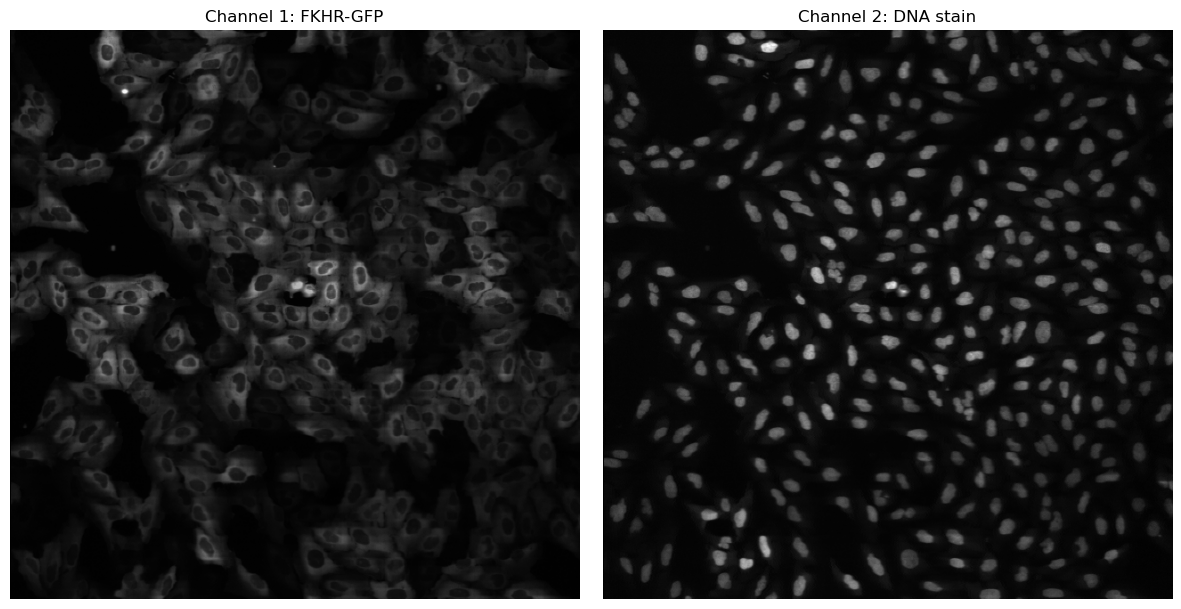

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(gfp_image, cmap="gray")
axes[0].set_title("Channel 1: FKHR-GFP")
axes[0].axis("off")

axes[1].imshow(nuclei_image, cmap="gray")
axes[1].set_title("Channel 2: DNA stain")
axes[1].axis("off")

plt.tight_layout()
plt.show()


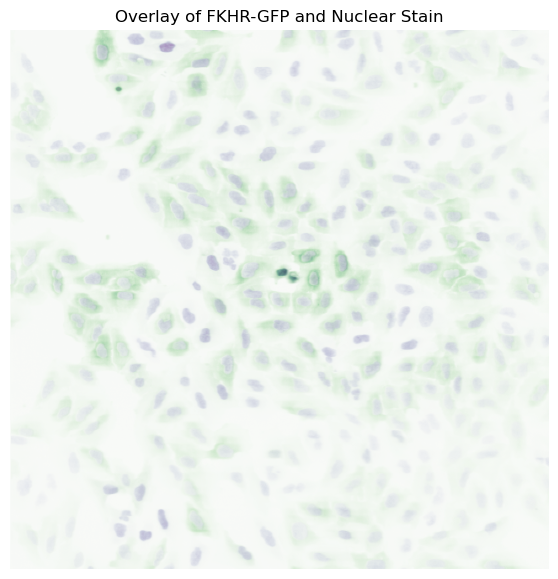

In [12]:
plt.figure(figsize=(7, 7))

plt.imshow(gfp_image, cmap="Greens", alpha=0.8)
plt.imshow(nuclei_image, cmap="Purples", alpha=0.4)

plt.title("Overlay of FKHR-GFP and Nuclear Stain")
plt.axis("off")

plt.show()

### Image structure

Each field of view contains two aligned grayscale images:

- Channel 1: FKHR-GFP fluorescence
- Channel 2: DNA nuclear staining

The nuclear channel will be used for nucleus segmentation, while the GFP channel will be used to quantify FKHR localisation.